# A* Algorithm - Labirinth path finding


## What is the A\* Algorithm

A* is a graph traversal and pathfinding algorithm that is used in many fields of computer science due to its completeness, optimality, and optimal efficiency. Given a weighted graph, a source node and a goal node, **the algorithm finds the shortest path from source to goal** (with respect to the given weights). This type of algorithm is an *informed search algorithm*, or a **best-first search algorithm**, meaning that algorithm selects the most promising node for expansion based on an evaluation function. It prioritizes nodes in the search space using a heuristic to estimate their potential. By iteratively choosing the most promising node, it aims to efficiently navigate towards the goal state, making it particularly effective for optimization problems.

## A brief historical explanation

A* was created as part of the **Shakey project**, which had the aim of building a mobile robot that could plan its own actions.
A* was originally designed for finding least-cost paths when the cost of a path is the sum of its costs, but it has been shown that A* can be used to find optimal paths for any problem satisfying the conditions of a cost algebra.

## How does it work?

Given a (weighted) graph, at each iteration of its main loop, A* needs to determine which of its paths to extend. It does so based on the cost of the path and an estimate of the cost required to extend the path all the way to the goal. Specifically, A* selects the path that minimizes

$$f(n)=g(n) + h(n)$$

where $n$ is the next node on the path, $g(n)$ is the cost of the path from the start node to $n$, and $h(n)$ is a heuristic function that estimates the cost of the cheapest path from $n$ to the goal. A* tipically uses a **priority queue** (called the open set, fringe, or frontier) to repeatedly select and expand nodes with the lowest estimated cost $f(n)$. The algorithm updates the cost $g(n)$ and $f(n)$ of neighboring nodes and adds them to the queue. It terminates when a goal node is reached, at which point $f(goal)$ represents the shortest path cost since the heuristic $h$ at the goal is zero for an admissible heuristic.

To retrieve the actual path, the algorithm can track each node's predecessor. By following these predecessors from the goal node back to the start, the sequence of steps in the shortest path can be reconstructed.

## Shedding light on the heuristic

**A heuristic function, also simply called a heuristic, is a function that ranks alternatives in search algorithms at each branching step** based on available information to decide which branch to follow. **The heuristic function is problem-specific**. As an example, when searching for the shortest route on a map, $h(x)$ might represent the straight-line distance to the goal, since that is physically the smallest possible distance between any two points. For a grid map from a video game, using the Taxicab/Manhattan distance or the Chebyshev distance becomes better depending on the set of movements available (4-way or 8-way).

A heuristic is called **admissible** if it never overestimates the actual cost to reach the solution, meaning that for each node $n$, its heuristic estimate $h(n)$ is always less than or equal to the actual cost $h^{*}(n)$ to reach the goal. Formally:

$n$ is a node  
$h$ is a heuristic  
$h(n)$  is the estimated cost to reach a $goal$ from $n$  
$h^{*}(n)$ is the actual optimal cost to reach a $goal$ from $n$  
$h(n)$ is admissible if $\forall n$ if $h(n) \leq h^{*}(n)$

In the context of the A* algorithm, **the admissibility of the heuristic implies that the algorithm itself will be optimal**, meaning that it will always find an optimal solution if one exists. Attention: **IF IT EXISTS!**

The admissibility of the heuristic guarantees optimality, however, **optimality does not imply completeness**: A* may take infinite time or fail to find a solution even though it remains optimal in theory.
For A* to always be complete, i.e. to find the otimal solution in a finite amount of time, two additional conditions must be met:

- **Positive edge costs**: If the edge costs are always greater than a certain positive threshold, A* will not risk getting stuck in infinite cycles with zero cost.
- **Finite number of explorable nodes**: If the search space is finite, A* will eventually explore all the necessary nodes to find the solution.

If these conditions are met, then the admissibility of the heuristic also guarantees completeness.
In summary: admissibility ensures optimality, but completeness requires additional constraints to ensure the algorithm actually finds a solution.

If the heuristic $h$ satisfies the additional condition $h(x) \leq d(x, y) + h(y)$ for every edge from node $x$ to node $y$ of the graph (where $d$ denotes the length of that edge), then $h$ is called monotonic, or **consistent**. **With a consistent heuristic, A\* is guaranteed to find an optimal path without processing any node more than once**. In fact, A* becomes equivalent to running Dijkstra's algorithm with a modified cost function $d'(x, y) = d(x, y) + h(y) − h(x)$.

Every consistent heuristic is also admissible (i.e. it never overestimates the true cost to reach the goal),
but not every admissible heuristic is consistent.

✅ If the heuristic is only admissible → A* is optimal and complete in finite search spaces with positive edge costs.

✅ If the heuristic is also consistent → A* is always guaranteed to be optimal and complete and it will process a node only once.

Note: Dijkstra's algorithm, as another example of a uniform-cost search algorithm, can be viewed as a special case of A* where ⁠$h(x) = 0$ for all $x$.


## About correctness  

While searching through manuals and online resources, I found it difficult to locate a rigorous proof of the correctness of the A* algorithm and not just an intuitive idea.  
Thus, I propose a proof, hopefully correct, that aims to be as simple and accurate as possible.  

Assume that A* has found a certain path $P_1$ within a graph with a starting node $S$ and a goal node $G$, with an associated cost $C(P_1)$ (which we can interpret as the *f-score*).  
**By contradiction**, suppose that there exists another path $P_2$ such that $C(P_2) < C(P_1)$, meaning that $P_1$ is not the optimal path.  

If $C(P_2) < C(P_1)$ $\Rightarrow$ $\exist n \in P_1$ s.t. $C(P_2) = C(n)$.  

Now, consider the node $n'$, which is the predecessor of $g$ in the path $P_2$. We then have $C(n') < C(n)$.  

Since the A* algorithm has selected $P_1$ as the path, it must have expanded a sequence of nodes with a cost (or *f-score*) greater than $C(n')$. ⚡  
**This contradicts the use of a priority queue**, which selects nodes based on their cost as the 'key'.  

In the case where no node $n$ exists such that $C(P_2) = C(n)$, there must exist two nodes $n_1$ and $n_2$ such that $C(n_1) \leq C(P_2) \leq C(n_2)$.  
It is then sufficient to consider $n_2$ and repeat the previous argument to reach a contradiction.  


## About complexity

The time complexity of A* depends on the heuristic. In the worst case of an unbounded search space, the number of nodes expanded is exponential in the depth of the solution (the shortest path) $d$: $O(b^d)$, where $b$ is the *branching factor* (the average number of successors per state).
One could think of giving the time-complexity in termes of the size of the graph and therefore it should be $O((|V|+|E|)⋅log|V|)$.

These are basically two different perspectives or two different ways of viewing the running time. Both are valid (neither is incorrect), but $O(b^d)$
is arguably more useful.

In the algorithms and CS communities people tend to like to count the running time as a function of the number of vertices and edges in the graph. In that context, worst-case running time is what makes most sense; also, in the problems that are typically considered in that community, in the worst case we need to examine the entire graph, so you typically can't hope to do better than $O(|V|+|E|)$


In the AI community people often consider a specific kind of graph: a tree with branching factor $b$. Also, in the situations that arise there, the graph is often infinite or very large. Typically we try hard to avoid examining all of the graph -- that's often one of the major goals of the algorithms. Thus, **counting complexity in terms of $|V|$ and $|E|$ doesn't make sense: $|V|$ may be infinite, and in any case, we don't plan on examining all of the graph**, so all that matters is the number of vertices we actually visit, not the number that may exist elsewhere but that we don't care about.

So, for the situations that often arise in the AI community, **it's more meaningful to measure the running time in terms of the branching factor of the tree ($b$) and the depth of the goal node ($d$)**. Typically, once we find the goal node, the algorithm stops. In such a tree, if we examine every vertex at depth $\leq d$ before we find the goal node, we'll end up visiting $O(b^d)$ vertices before we stop. Thusit is possible to think of this as visiting a subset of the graph with $|V|=O(b^d)$ (where now $V$ includes only the vertices we visit) and $|E|=O(b^d)$ ($E$ includes only the edges we look at), and you could think of an $O(b^d)$-time algorithm as one whose running time is $O(|V|+|E|)$... though this is a bit of an abuse of the $|V|,|E|$ notation.

## An easy example

In this first application of the A* algorithm we consider a 15x15 grid (225 points in total) from which we remove 60 random points.
The grid must be seen as a graph made of nodes (the remaining points) and invisibile edges between adjacent points (i.e. points with |$\Delta x| < 1$ or |$\Delta y| < 1$).

The starting node will be the node in the bottom left corner, the goal node will be in the top right corner.
To avoid to eliminate the start node or the goal node they are added to a special list called "protected_points".

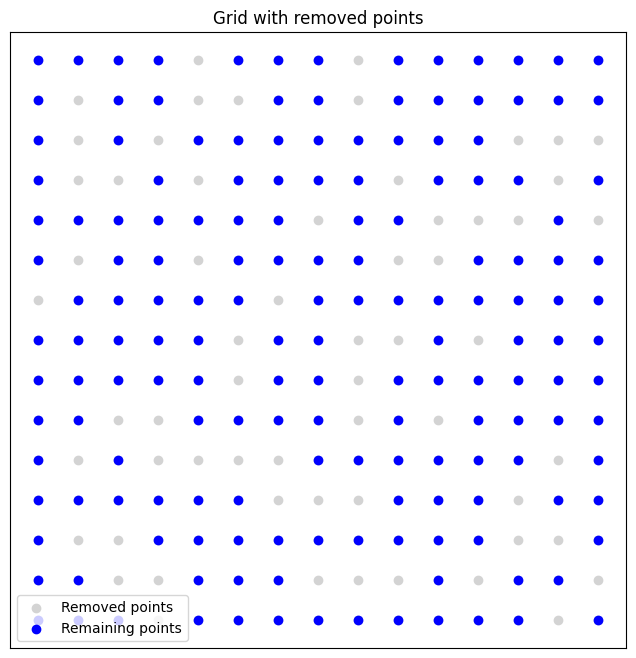

The remaining points have been saved in 'remaining_points.csv'


In [ ]:
import random
import csv
import matplotlib.pyplot as plt

# Grid size
grid_size = 15

# Generate all the points of the grid
all_points = [(x, y) for x in range(grid_size) for y in range(grid_size)]

# Points that must not be removed
protected_points = [(0, 0), (14, 14)]

# Removable points
removable_points = [point for point in all_points if point not in protected_points]

# Remove random points from the removable points
remaining_points = protected_points + random.sample(removable_points, len(removable_points) - 60)

# Save the remaining points in a CSV file
output_file = 'remaining_points.csv'
with open(output_file, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(['x', 'y'])  # File header
    csv_writer.writerows(remaining_points)

# Plot of the grid
remaining_x, remaining_y = zip(*remaining_points)
all_x, all_y = zip(*all_points)

plt.figure(figsize=(8, 8))
plt.scatter(all_x, all_y, color='lightgray', label='Removed points')
plt.scatter(remaining_x, remaining_y, color='blue', label='Remaining points')
plt.title('Grid with removed points')
plt.legend()

# Remove the ticks on the x and y axes
ax = plt.gca()  # Get the current axes object
ax.set_xticks([])
ax.set_yticks([])

ax.set_aspect('equal', adjustable='box')  # Set equal aspect ratio
plt.show()

print(f"The remaining points have been saved in '{output_file}'")


Now it's time to implement the algorithm.  
Additionally, we can include a function, called animate_a_star, to generate a GIF that visualizes the algorithm's progress and its traversal through the graph.

Generated nodes (N): 74
Path found: [Node(0, 0), Node(0, 1), Node(0, 2), Node(0, 3), Node(0, 4), Node(0, 5), Node(0, 6), Node(0, 7), Node(1, 7), Node(2, 7), Node(2, 8), Node(2, 9), Node(2, 10), Node(3, 10), Node(4, 10), Node(5, 10), Node(6, 10), Node(6, 11), Node(6, 12), Node(7, 12), Node(8, 12), Node(9, 12), Node(9, 13), Node(9, 14), Node(10, 14), Node(11, 14), Node(12, 14), Node(13, 14), Node(14, 14)]
fScore of the goal: 28


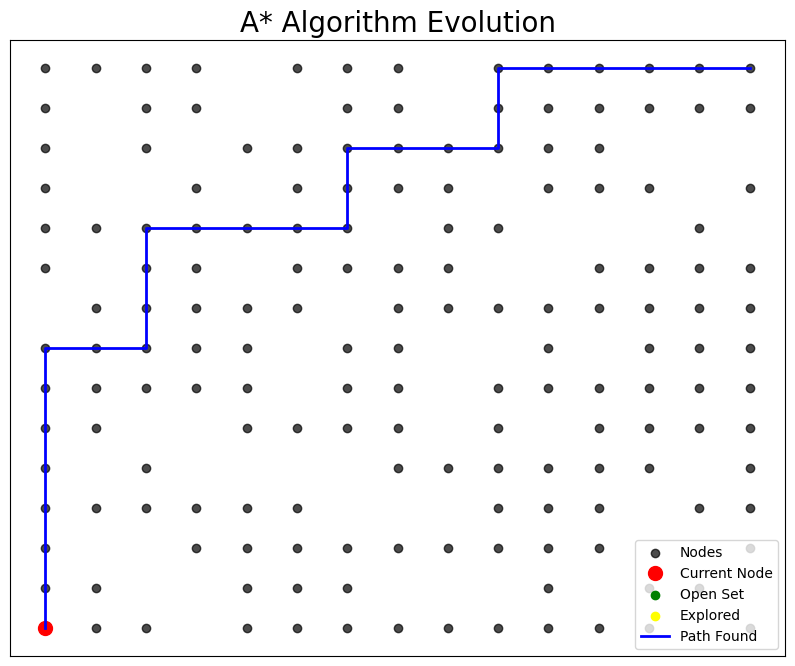

In [ ]:
import math
from matplotlib.animation import FuncAnimation

class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"Node({self.x}, {self.y})"

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __hash__(self):
        return hash((self.x, self.y))

# Reading the CSV file and creating the nodes
coordinates = []
with open("remaining_points.csv", "r") as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  # Skip the header
    for row in csv_reader:
        x, y = map(int, row)
        coordinates.append((x, y))

# Creating the nodes
nodes = [Node(x, y) for x, y in coordinates]

def neighbors(node):
    # Define the movements for right, left, up, down
    deltas = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    neighbors_list = []

    for delta_x, delta_y in deltas:
        # Calculate the new coordinates x and y
        x_new = node.x + delta_x
        y_new = node.y + delta_y

        # Create a new node
        neighbor_node = Node(x_new, y_new)

        # Check if the calculated node is in the initial list
        if neighbor_node in nodes:  # Assuming 'nodes' is defined elsewhere
            neighbors_list.append(neighbor_node)

    return neighbors_list

def h(node, goal):
    return abs(goal.x - node.x) + abs(goal.y - node.y)


def reconstruct_path(cameFrom, current):
    total_path = [current]
    while current in cameFrom:
        current = cameFrom[current]
        total_path.insert(0, current)
    return total_path

def a_star(start, goal, h, neighbors, save_steps=False):
    openSet = {start}
    cameFrom = {}
    gScore = {node: float('inf') for node in nodes}
    gScore[start] = 0
    fScore = {node: float('inf') for node in nodes}
    fScore[start] = h(start, goal)

    steps = [] if save_steps else None
    explored = set()
    generated_nodes = set()  # Set to track all generated nodes
    generated_nodes.add(start)

    while openSet:
        current = min(openSet, key=lambda node: fScore[node])
        if save_steps:
            steps.append({"current": current, "openSet": set(openSet), "explored": set(explored)})
        if current == goal:
            print(f"Generated nodes (N): {len(generated_nodes)}")  # Print N
            return reconstruct_path(cameFrom, current), fScore, steps
        openSet.remove(current)
        explored.add(current)
        for neighbor in neighbors(current):
            tentative_gScore = gScore[current] + 1
            if tentative_gScore < gScore[neighbor]:
                cameFrom[neighbor] = current
                gScore[neighbor] = tentative_gScore
                fScore[neighbor] = tentative_gScore + h(neighbor, goal)
                if neighbor not in openSet and neighbor not in explored:
                    openSet.add(neighbor)
                    generated_nodes.add(neighbor)  # Add to the set of generated nodes
    print(f"Generated nodes (N): {len(generated_nodes)}")  # Print N
    return None, fScore, steps

def animate_a_star(steps, nodes, path):
    fig, ax = plt.subplots(figsize=(10, 8))
    all_x, all_y = zip(*[(node.x, node.y) for node in nodes])
    path_coordinates = [(node.x, node.y) for node in path] if path else []
    ax.scatter(all_x, all_y, c='black', alpha=0.7, label='Nodes')
    ax.grid(False)
    ax.legend()
    ax.set_title("A* Algorithm Evolution", fontsize=20)
    ax.set_xticks([])  # Removes x-axis ticks
    ax.set_yticks([])  # Removes y-axis ticks

    current_marker, = ax.plot([], [], "ro", label="Current Node", markersize=10)
    openSet_scatter = ax.scatter([], [], c="green", label="Open Set")
    explored_scatter = ax.scatter([], [], c="yellow", label="Explored")
    path_line, = ax.plot([], [], c="blue", linewidth=2, label="Path Found")

    def update(frame):
        state = steps[frame]
        current_node = state["current"]
        openSet = state["openSet"]
        explored = state["explored"]

        current_marker.set_data([current_node.x], [current_node.y])
        explored_coords = [(node.x, node.y) for node in explored] if explored else [(0, 0)]
        openSet_coords = [(node.x, node.y) for node in openSet] if openSet else [(0, 0)]

        openSet_scatter.set_offsets(openSet_coords)
        explored_scatter.set_offsets(explored_coords)

        if path:
            path_x, path_y = zip(*path_coordinates)
            path_line.set_data(path_x, path_y)

    ani = FuncAnimation(fig, update, frames=len(steps), repeat=False, interval=200)
    plt.legend()
    return ani

start_node = Node(0, 0)
goal_node = Node(14, 14)
start = next((node for node in nodes if node.x == start_node.x and node.y == start_node.y), None)
goal = next((node for node in nodes if node.x == goal_node.x and node.y == goal_node.y), None)
if start is None:
    print("Start node not found in the list of nodes.")
if goal is None:
    print("Goal node not found in the list of nodes.")
path, fScore, steps = a_star(start, goal, h, neighbors, save_steps=True)
if path:
    print("Path found:", path)
    print("fScore of the goal:", fScore[goal])
    animation = animate_a_star(steps, nodes, path)
    animation.save('a_star_animation.gif', writer='pillow', fps=5)
else:
    print("No path found.")


## Again about complexity

The heuristic function has a major effect on the practical performance of A* search, since a good heuristic allows A* to prune away many of the $b^d$ nodes that an uninformed search would expand. Its quality can be expressed in terms of the **effective branching factor $b^*$**, which can be determined empirically for a problem instance by measuring the number of nodes generated by expansion $N$, and the depth of the solution, then solving:
$$ N + 1 = 1 + (b^*)^1 + (b^*)^2 + ... + (b^*)^d $$

Good heuristics are those with low effective branching factor (the optimal being $b^* = 1$).  
Here we consider two different types of heuristics:  

- **Euclidean**: $h(node) = \sqrt{(goal.x - node.x)^2 + (goal.y - node.y)^2}$  

- **Manhattan**: $h(node) = |goal.x - node.x| + |goal.y - node.y|$

And we keep track of $N$ and compute $b*$:


In [ ]:
import numpy as np
import math
import time

def h_euclidean(node, goal):
    return math.sqrt((goal.x - node.x) ** 2 + (goal.y - node.y) ** 2)

def h_manhattan(node, goal):
    return abs(goal.x - node.x) + abs(goal.y - node.y)

def calculate_b_star(N, d):
    """
    Calculates the effective branching factor b* given N and d.
    Solves the equation N + 1 = 1 + b* + (b*)^2 + ... + (b*)^d numerically.
    """
    def equation(b_star):
        return sum(b_star ** i for i in range(d + 1)) - (N + 1)

    b_star_guess = 1.0
    tolerance = 1e-6
    max_iterations = 100

    for _ in range(max_iterations):
        eq_value = equation(b_star_guess)
        if abs(eq_value) < tolerance:
            return b_star_guess
        derivative = sum(i * b_star_guess ** (i - 1) for i in range(1, d + 1))
        b_star_guess -= eq_value / derivative

    return b_star_guess

def compute_b_star_for_heuristic(h, start, goal, neighbors):
    """
    Runs A* with a given heuristic h and calculates the effective branching factor b*.
    """
    start_time = time.time()  # Start of the timer

    # Assuming a_star is already defined elsewhere
    path, fScore, steps = a_star(start, goal, h, neighbors, save_steps=True)

    generated_nodes = set()
    for step in steps:
        generated_nodes.update(step["openSet"])
        generated_nodes.update(step["explored"])

    d = len(path) - 1
    N = len(generated_nodes)

    execution_time = time.time() - start_time  # Execution time

    if d > 0:
        b_star = calculate_b_star(N, d)
        return b_star, N, execution_time
    else:
        return None, N, execution_time

heuristics = {
    "Euclidean": h_euclidean,
    "Manhattan": h_manhattan
}

for name, heuristic in heuristics.items():
    b_star, N, execution_time = compute_b_star_for_heuristic(heuristic, start, goal, neighbors)
    print(f"Effective branching factor b* with {name}: {b_star}, N: {N}, Execution time: {execution_time:.6f} seconds")


Generated nodes (N): 127
Effective branching factor b* with Euclidean: 1.0917127718571888, N: 127, Execution time: 0.036117 seconds
Generated nodes (N): 74
Effective branching factor b* with Manhattan: 1.0610826999303555, N: 74, Execution time: 0.008460 seconds


As shown, the effective branching factor is just over 1. This indicates that each time a new node is explored and subsequently "closed," the heuristic typically directs the search toward a well-defined adjacent node, often the correct one, thereby avoiding the evaluation of unnecessary $fscore$ values.

For both $N$ and $b^*$, the Manhattan heuristic yields better values. This directly implies an improvement in execution time!
A good choice of $h$ not only ensures the existence of a solution but also improves the algorithm's efficiency, saving time.

## On to the heavy lifting

Until now, we've tested the A* algorithm on a small graph with 165 nodes.
Now, let’s move on to something more challenging: an intricate maze.

The PNG below represents a rather tricky maze. The white areas are the possible paths, and the black areas are the walls—nothing new so far, right? First things first, we need a way to "translate" this PNG into a graph. We want to extract a list of available points (the nodes) and model them as a large graph.

<img src="maze.jpg" alt="Maze" width="600">

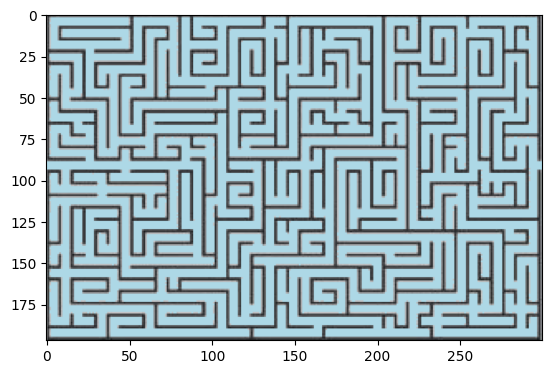

Number of nodes found: 36962
Nodes saved to file: c:\Users\feder\OneDrive\Desktop\Strutture dati e algoritmi\Progetto SDA\nodes_maze.csv


In [ ]:
from PIL import Image
import os
import csv

# Function to generate the collision map
def generate_collision_map(image_path, obstacle_color=(0, 0, 0), color_tolerance=200):
    # Load the image
    img = Image.open(image_path)

    # If the image has an alpha channel, we remove it to focus only on RGB colors
    img = img.convert("RGB")

    width, height = img.size
    nodes = []

    # Iterate over each pixel in the image
    for y in range(height):
        for x in range(width):
            # Get the pixel color (R, G, B)
            pixel = img.getpixel((x, y))

            # Check if the pixel is NOT black, meaning it's a traversable node
            if not is_color_similar(pixel, obstacle_color, color_tolerance):
                nodes.append((x, y))  # Add the node's coordinates

    return nodes


# Function to check if a color is similar to another considering the tolerance
def is_color_similar(color1, color2, tolerance):
    return all(abs(color1[i] - color2[i]) <= tolerance for i in range(3))

# Function to save the nodes to a CSV file
def save_nodes_to_csv(nodes, csv_filename):
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])  # CSV file header
        writer.writerows(nodes)  # Write all nodes to the file

# Function to display the nodes on a map
def display_nodes_on_map(image_path, nodes):
    # Load the original image
    img = Image.open(image_path)

    # Create a black-and-white image of the same size
    img_with_nodes = img.convert("RGB")
    pixels = img_with_nodes.load()

    # Color the found nodes (e.g., using light blue)
    for (x, y) in nodes:
        pixels[x, y] = (173, 216, 230)  # Light blue color for the nodes

    # Display the image with the nodes overlaid
    plt.imshow(img_with_nodes)
    plt.show()

# Relative path of the 'monza.png' image in the same folder as the code
collision_map_image = os.path.join(os.getcwd(), 'maze.jpg')

# Generate the list of nodes
nodes = generate_collision_map(collision_map_image)

# Save the nodes to a CSV file
csv_output_path = os.path.join(os.getcwd(), 'nodes_maze.csv')
save_nodes_to_csv(nodes, csv_output_path)

# Display the nodes on the image
display_nodes_on_map(collision_map_image, nodes)

print(f"Number of nodes found: {len(nodes)}")
print(f"Nodes saved to file: {csv_output_path}")


The blue sky areas of the maze are now points saved as a couple $(x, y)$ in the .csv file, while the black parts could be seen as the "absence" of points, i.e. walls.

In [ ]:
import time
import csv

# Start time calculation
start_time = time.time()

# Reading the CSV file and creating the nodes
coordinates = []
with open("nodes_maze.csv", "r") as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  # Skip the header
    for row in csv_reader:
        x, y = map(int, row)
        coordinates.append((x, y))

# Creating the nodes
nodes = [Node(x, y) for x, y in coordinates]


def a_star(start, goal, h, neighbors):
    openSet = {start}
    cameFrom = {}

    gScore = {node: float('inf') for node in nodes}
    gScore[start] = 0

    fScore = {node: float('inf') for node in nodes}
    fScore[start] = h(start, goal)

    while openSet:
        current = min(openSet, key=lambda node: fScore[node])

        if current == goal:
            return reconstruct_path(cameFrom, current), fScore

        openSet.remove(current)

        for neighbor in neighbors(current):
            tentative_gScore = gScore[current] + 1

            if tentative_gScore < gScore[neighbor]:
                cameFrom[neighbor] = current
                gScore[neighbor] = tentative_gScore
                fScore[neighbor] = tentative_gScore + h(neighbor, goal)

                if neighbor not in openSet:
                    openSet.add(neighbor)

    return None, fScore


# Function to plot the nodes
def plot_nodes(nodes, path):
    # Extract the path nodes
    path_coordinates = [(node.x, node.y) for node in path] if path else []

    # Collect nodes for coloring
    path_x, path_y = zip(*path_coordinates) if path else ([], [])
    all_x, all_y = zip(*[(node.x, node.y) for node in nodes])

    # Nodes not belonging to the path
    non_path_x = [x for x, y in zip(all_x, all_y) if (x, y) not in path_coordinates]
    non_path_y = [y for x, y in zip(all_x, all_y) if (x, y) not in path_coordinates]

    # Plot the nodes
    plt.figure(figsize=(10, 8))
    plt.scatter(non_path_x, non_path_y, c='black', label='Nodes (not in the path)', alpha=0.7)
    if path:
        plt.plot(path_x, path_y, c='blue', label='Found path', linewidth=2, marker='o')

    # Customize the plot
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Visualization of nodes and path")
    plt.grid(True)
    plt.legend()

    # Invert the y-axis
    plt.gca().invert_yaxis()

    plt.show()


# Function to save the path to a CSV file
def save_path_to_csv(path, filename="pathmaze.csv"):
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["x", "y"])  # Header
        for node in path:
            writer.writerow([node.x, node.y])


# Set the start and goal node
start_node = Node(1, 90)
goal_node = Node(299, 90)

# Find the corresponding nodes in the nodes list
start = next((node for node in nodes if node.x == start_node.x and node.y == start_node.y), None)
goal = next((node for node in nodes if node.x == goal_node.x and node.y == goal_node.y), None)

# Verify that the nodes are valid
if start is None:
    print("Start node not found in the node list.")
if goal is None:
    print("Goal node not found in the node list.")

# Run the A* algorithm (make sure start and goal are found correctly)
path, fScore = a_star(start, goal, h, neighbors)

# Print the found path and the fScore of the goal
if path:
    print("Path found:", path)
    print("fScore of the goal (shortest path):", fScore[goal])
    # plot_nodes(nodes, path)
    save_path_to_csv(path)  # Save the path to a CSV file
else:
    print("No path found.")

end_time = time.time()
runtime = end_time - start_time
print(f"Program execution time: {runtime:.4f} seconds")


Path found: [Node(1, 90), Node(2, 90), Node(3, 90), Node(4, 90), Node(5, 90), Node(6, 90), Node(7, 90), Node(8, 90), Node(9, 90), Node(10, 90), Node(11, 90), Node(12, 90), Node(13, 90), Node(13, 91), Node(13, 92), Node(13, 93), Node(13, 94), Node(13, 95), Node(13, 96), Node(13, 97), Node(13, 98), Node(13, 99), Node(13, 100), Node(13, 101), Node(13, 102), Node(13, 103), Node(14, 103), Node(14, 104), Node(15, 104), Node(16, 104), Node(17, 104), Node(18, 104), Node(19, 104), Node(20, 104), Node(21, 104), Node(22, 104), Node(23, 104), Node(24, 104), Node(25, 104), Node(26, 104), Node(27, 104), Node(28, 104), Node(29, 104), Node(30, 104), Node(31, 104), Node(32, 104), Node(32, 105), Node(32, 106), Node(32, 107), Node(32, 108), Node(32, 109), Node(32, 110), Node(32, 111), Node(31, 111), Node(30, 111), Node(29, 111), Node(28, 111), Node(27, 111), Node(26, 111), Node(25, 111), Node(24, 111), Node(23, 111), Node(22, 111), Node(21, 111), Node(20, 111), Node(19, 111), Node(18, 111), Node(17, 111)

After saving the path is sufficient to draw it on the original png to see the magic trick.

In [ ]:
from PIL import Image, ImageDraw

# Function to load points from the CSV file
def load_points_from_csv(filename="pathmaze.csv"):
    points = []
    with open(filename, mode='r') as file:
        csv_reader = csv.reader(file)
        next(csv_reader)  # Skip the header
        for row in csv_reader:
            x, y = map(int, row)
            points.append((x, y))
    return points

# Function to draw points on an image
def draw_points_on_image(image_path, points, output_image_path="output_maze.jpg", radius=2):
    # Load the image
    img = Image.open(image_path)
    draw = ImageDraw.Draw(img)

    # Draw the points as blue circles
    for point in points:
        x, y = point
        draw.ellipse([x - radius, y - radius, x + radius, y + radius], fill="blue", outline="blue")

    # Save the resulting image
    img.save(output_image_path)

# Load the points from the CSV file
points = load_points_from_csv("pathmaze.csv")

# Draw the points on the image and save the result
draw_points_on_image("maze.jpg", points, "output_maze.jpg")


<img src="output_maze.jpg" alt="Maze" width="600">

## A much strange application

The last example proposed about the application of A* is about the Barcelona circuit.  
We would like to trace the shortest path of the circuit, using A*.

Even in this case we have at our disposal just the png image of the circuit, and we need to convert the track into nodes.

<img src="barcellona.jpg" alt="Maze" width="800">

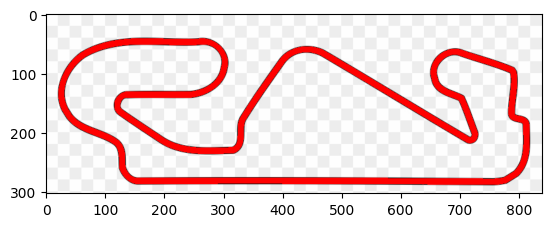

Numero di nodi trovati: 28425
Nodi salvati nel file: c:\Users\feder\OneDrive\Desktop\Strutture dati e algoritmi\Progetto SDA\nodi_barcellona.csv


In [ ]:
# Funzione per generare la mappa di collisione
def generate_collision_map(image_path, track_color=(0, 0, 0), obstacle_color=(255, 255, 255), color_tolerance=10):
    # Carica l'immagine
    img = Image.open(image_path)

    # Se l'immagine ha un canale alfa, la rimuoviamo per concentrarci solo sui colori RGB
    img = img.convert("RGB")

    width, height = img.size
    nodes = []

    # Scorri ogni pixel dell'immagine
    for y in range(height):
        for x in range(width):
            # Ottieni il colore del pixel (R, G, B)
            pixel = img.getpixel((x, y))

            # Verifica se il pixel è simile al colore della traccia (usando tolleranza)
            if is_color_similar(pixel, track_color, color_tolerance):
                nodes.append((x, y))  # Aggiungi le coordinate del nodo

    return nodes

# Funzione per verificare se un colore è simile a un altro considerando la tolleranza
def is_color_similar(color1, color2, tolerance):
    return all(abs(color1[i] - color2[i]) <= tolerance for i in range(3))

# Funzione per salvare i nodi in un file CSV
def save_nodes_to_csv(nodes, csv_filename):
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])  # Intestazione del file CSV
        writer.writerows(nodes)  # Scrive tutti i nodi nel file

# Funzione per visualizzare i nodi su una mappa
def display_nodes_on_map(image_path, nodes):
    # Carica l'immagine originale
    img = Image.open(image_path)

    # Crea un'immagine in bianco e nero della stessa dimensione
    img_with_nodes = img.convert("RGB")
    pixels = img_with_nodes.load()

    # Colora i nodi trovati (ad esempio, con il colore rosso)
    for (x, y) in nodes:
        pixels[x, y] = (255, 0, 0)  # Colore rosso per i nodi

    # Visualizza l'immagine con i nodi sovrapposti
    plt.imshow(img_with_nodes)
    plt.show()

# Percorso relativo dell'immagine 'monza.png' nella stessa cartella del codice
collision_map_image = os.path.join(os.getcwd(), 'barcellona.jpg')

# Genera la lista dei nodi
nodes = generate_collision_map(collision_map_image)

# Salva i nodi in un file CSV
csv_output_path = os.path.join(os.getcwd(), 'nodi_barcellona.csv')
save_nodes_to_csv(nodes, csv_output_path)

# Visualizza i nodi sull'immagine
display_nodes_on_map(collision_map_image, nodes)

print(f"Numero di nodi trovati: {len(nodes)}")
print(f"Nodi salvati nel file: {csv_output_path}")


In [ ]:
import pandas as pd

df = pd.read_csv("nodi_barcellona.csv")

# Remove the line of nodes with x = 550 in order to simulate the finish line
df_filtered = df[~((df['x'] == 550) & (df['y'] >= 250) & (df['y'] <= 300))]

df_filtered.to_csv("nodes_barcelona_filtered.csv", index=False)

print("File saved as 'nodes_barcelona_filtered.csv'")


File saved as 'nodes_barcelona_filtered.csv'


In [ ]:
# Reading the CSV file and creating the nodes
coordinates = []
with open("nodes_barcelona_filtered.csv", "r") as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  # Skip the header
    for row in csv_reader:
        x, y = map(int, row)
        coordinates.append((x, y))

# Creating the nodes
nodes = [Node(x, y) for x, y in coordinates]

# Function to save the path to a CSV file
def save_path_to_csv(path, filename="pathbarca.csv"):
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["x", "y"])  # Header
        for node in path:
            writer.writerow([node.x, node.y])

# Set the start and goal node
start_node = Node(549,281)
goal_node = Node(551,281)

# Find the corresponding nodes in the nodes list
start = next((node for node in nodes if node.x == start_node.x and node.y == start_node.y), None)
goal = next((node for node in nodes if node.x == goal_node.x and node.y == goal_node.y), None)

# Verify that the nodes are valid
if start is None:
    print("Start node not found in the node list.")
if goal is None:
    print("Goal node not found in the node list.")

# Run the A* algorithm (make sure start and goal are found correctly)
path, fScore = a_star(start, goal, h, neighbors)

# Print the found path and the fScore of the goal
if path:
    print("Path found:", path)
    print("fScore of the goal (shortest path):", fScore[goal])
    # plot_nodes(nodes, path)
    save_path_to_csv(path)  # Save the path to a CSV file
else:
    print("No path found.")



Path found: [Node(549, 281), Node(548, 281), Node(547, 281), Node(546, 281), Node(545, 281), Node(544, 281), Node(543, 281), Node(542, 281), Node(541, 281), Node(540, 281), Node(539, 281), Node(538, 281), Node(537, 281), Node(536, 281), Node(535, 281), Node(534, 281), Node(533, 281), Node(532, 281), Node(531, 281), Node(530, 281), Node(529, 281), Node(528, 281), Node(527, 281), Node(526, 281), Node(525, 281), Node(524, 281), Node(523, 281), Node(522, 281), Node(521, 281), Node(520, 281), Node(519, 281), Node(518, 281), Node(517, 281), Node(516, 281), Node(515, 281), Node(514, 281), Node(513, 281), Node(512, 281), Node(511, 281), Node(510, 281), Node(509, 281), Node(508, 281), Node(507, 281), Node(506, 281), Node(505, 281), Node(504, 281), Node(503, 281), Node(502, 281), Node(501, 281), Node(500, 281), Node(499, 281), Node(498, 281), Node(497, 281), Node(496, 281), Node(495, 281), Node(494, 281), Node(493, 281), Node(492, 281), Node(491, 281), Node(490, 281), Node(489, 281), Node(488, 2

In [ ]:
# Load the points from the CSV file
points = load_points_from_csv("pathbarca.csv")

# Draw the points on the image and save the result
draw_points_on_image("barcellona.jpg", points, "output_barca.jpg")

<img src="output_barca.jpg" alt="barca" width="800">